## DX799S O1 Data Science Capstone (Summer 1 2025): ACTIVITY 10.2 ##

Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone Two, create a Jupyter Notebook (similar to in Module B, semester two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data using the methods you have learned about in this course and in this program and draw interesting conclusions. 

For this week, include the following ideas: k-means; specifically elbow method, Silhouette score, feature scaling, and distance metrics. Complete your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In Week 12, you will compile your findings from your Jupyter Notebook homework into your Milestone Two assignment for grading. For full instructions and the rubric for Milestone Two, refer to the following link. 

In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np



In [84]:
#Video Review Dataset 

df_video_review = pd.read_csv("video_review.csv")

label_encoder = LabelEncoder()
for col in df_video_review.select_dtypes(include=['object']).columns:
    df_video_review[col] = label_encoder.fit_transform(df_video_review[col].astype(str))

X_video_review = df_video_review.drop(columns=['Primary_Impact_Type'])

scaler = StandardScaler()
X_video_review_scaled = scaler.fit_transform(X_video_review)


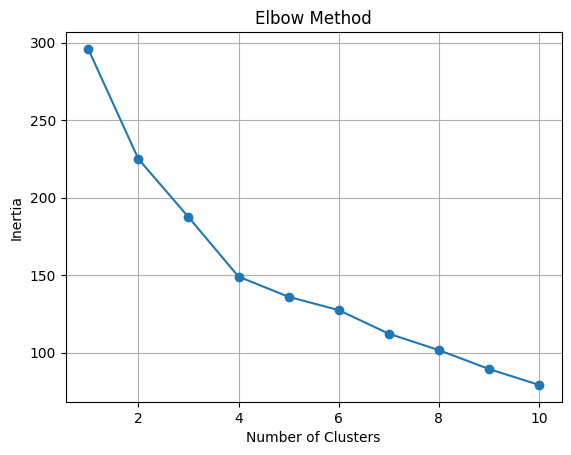

In [85]:
#Video Review Elbow Method

inertia_video = []
K_range_video = range(1, 11)
for k in K_range_video:
    kmeans_video = KMeans(n_clusters=k, random_state=42)
    kmeans_video.fit(X_video_review_scaled)
    inertia_video.append(kmeans_video.inertia_)

plt.plot(K_range_video, inertia_video, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()



k = 2, Silhouette Score = 0.2094
k = 3, Silhouette Score = 0.2042
k = 4, Silhouette Score = 0.2362
k = 5, Silhouette Score = 0.2041
k = 6, Silhouette Score = 0.1917
k = 7, Silhouette Score = 0.1770
k = 8, Silhouette Score = 0.1680
k = 9, Silhouette Score = 0.1798
k = 10, Silhouette Score = 0.1905


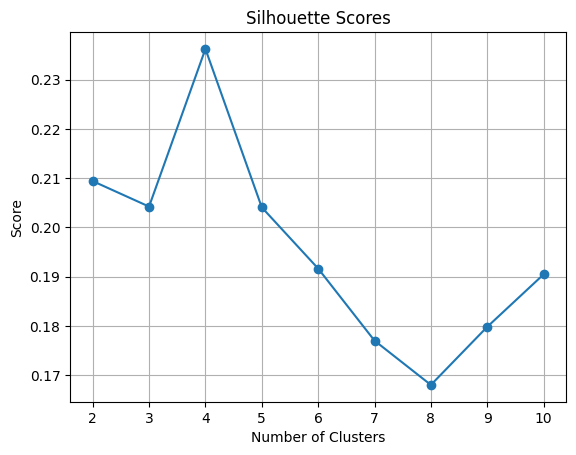

In [86]:
# Video Review Silhouette Scores 
sil_scores_video = []
for k_video in range(2, 11):
    kmeans_video = KMeans(n_clusters=k_video, random_state=42)
    labels_video = kmeans_video.fit_predict(X_video_review_scaled)
    score = silhouette_score(X_video_review_scaled, labels_video)
    sil_scores_video.append(score)
    print(f"k = {k_video}, Silhouette Score = {score:.4f}")

plt.plot(range(2, 11), sil_scores_video, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.grid(True)
plt.show()



In [87]:
# Video Review Model with Optimal k

optimal_k_video = 4 
kmeans_final_video = KMeans(n_clusters=optimal_k_video, random_state=42)
labels_final_video = kmeans_final_video.fit_predict(X_video_review_scaled)

final_sil_score = silhouette_score(X_video_review_scaled, labels_final_video)
print(f"Final Silhouette Score (k={optimal_k_video}): {final_sil_score:.4f}")


Final Silhouette Score (k=4): 0.2362


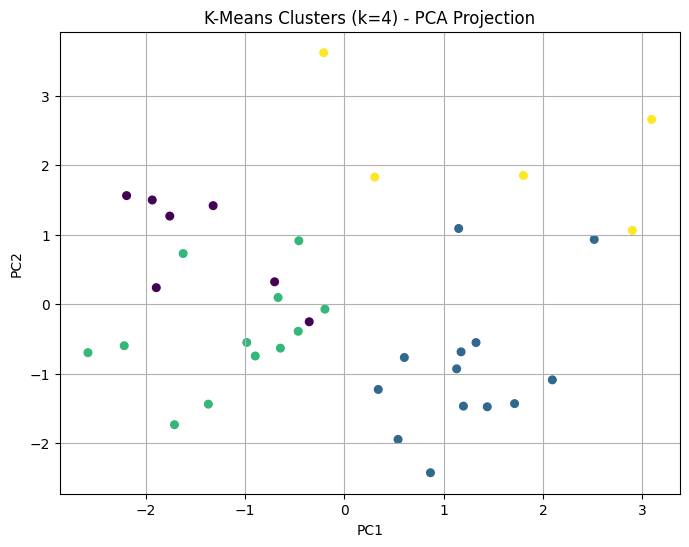

In [88]:
#Video Review PCA 

pca_video = PCA(n_components=2)
video_pca = pca_video.fit_transform(X_video_review_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(video_pca[:, 0], video_pca[:, 1], c=labels_final_video, cmap='viridis', s=30)
plt.title(f'K-Means Clusters (k={optimal_k_video}) - PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

In [89]:
#Injury Record Dataset

injury_df = pd.read_csv("InjuryRecord.csv")

injury_label_encoder = LabelEncoder()
for col in injury_df.select_dtypes(include=['object']).columns:
    injury_df[col] = injury_label_encoder.fit_transform(injury_df[col].astype(str))

X_injury = injury_df.drop(columns=['Surface'])

injury_scaler = StandardScaler()
X_injury_scaled = injury_scaler.fit_transform(X_injury)


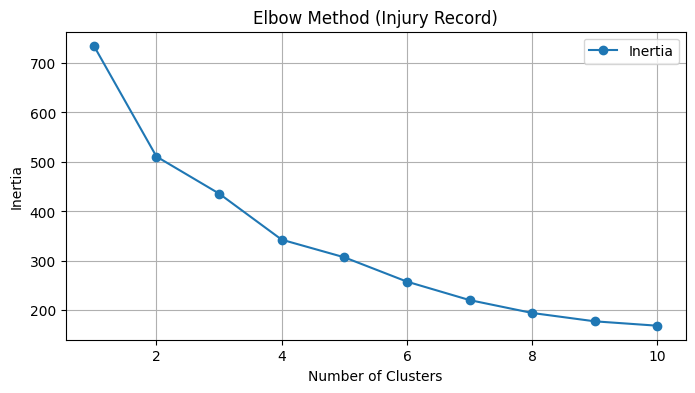

In [90]:
# Injury Record Elbow Method
inertia_injury = []
K_range_injury = range(1, 11)
for k in K_range_injury:
    kmeans_injury = KMeans(n_clusters=k, random_state=42)
    kmeans_injury.fit(X_injury_scaled)
    inertia_injury.append(kmeans_injury.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range_injury, inertia_injury, marker='o', label='Inertia')
plt.title('Elbow Method (Injury Record)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.legend()
plt.show()



k = 2, Silhouette Score = 0.2987
k = 3, Silhouette Score = 0.2589
k = 4, Silhouette Score = 0.2758
k = 5, Silhouette Score = 0.2820
k = 6, Silhouette Score = 0.3132
k = 7, Silhouette Score = 0.3121
k = 8, Silhouette Score = 0.3552
k = 9, Silhouette Score = 0.3616
k = 10, Silhouette Score = 0.3455


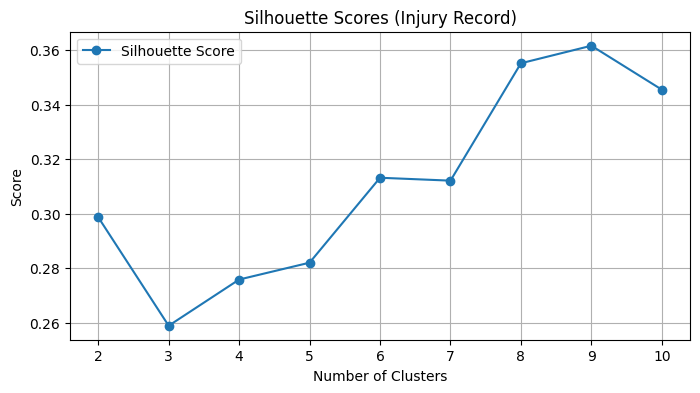

In [91]:
# Injury Record Silhouette Score
sil_scores_injury = []
for k_injury in range(2, 11):
    kmeans_injury = KMeans(n_clusters=k_injury, random_state=42)
    labels_injury = kmeans_injury.fit_predict(X_injury_scaled)
    score = silhouette_score(X_injury_scaled, labels_injury)
    sil_scores_injury.append(score)
    print(f"k = {k_injury}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), sil_scores_injury, marker='o', label='Silhouette Score')
plt.title('Silhouette Scores (Injury Record)')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()


In [92]:
#Injury Record Model with Optimal k
optimal_k_injury = 9  
kmeans_final_injury = KMeans(n_clusters=optimal_k_injury, random_state=42)
labels_final_injury = kmeans_final_injury.fit_predict(X_injury_scaled)

final_sil_score_injury = silhouette_score(X_injury_scaled, labels_final_injury)
print(f"Final Silhouette Score (k={optimal_k_injury}): {final_sil_score_injury:.4f}")


Final Silhouette Score (k=9): 0.3616


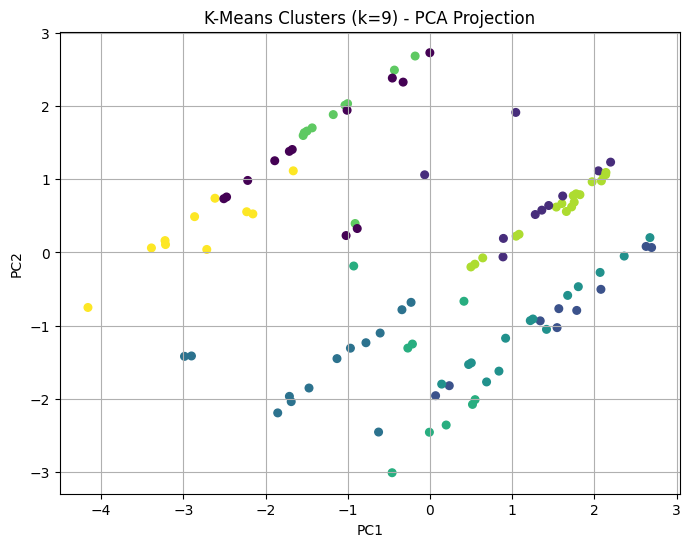

In [93]:
# Injury Record PCA Visualization

optimal_k_injury = 9  
kmeans_final_injury = KMeans(n_clusters=optimal_k_injury, random_state=42)
labels_final_injury = kmeans_final_injury.fit_predict(X_injury_scaled)

pca_injury = PCA(n_components=2)
injury_pca = pca_injury.fit_transform(X_injury_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(injury_pca[:, 0], injury_pca[:, 1], c=labels_final_injury, cmap='viridis', s=30)
plt.title(f'K-Means Clusters (k={optimal_k_injury}) - PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)

In [94]:
#Concussion Dataset 

df_concussion = pd.read_csv("Concussion Injuries 2012-2014 (1).csv")
df_clean_concussion = df_concussion.drop(columns=['ID', 'Player', 'Game', 'Date', 'Winning Team?', 'Unknown Injury?'])
df_clean_concussion = df_clean_concussion.dropna()

label_encoder = LabelEncoder()
for col in df_clean_concussion.select_dtypes(include=['object']).columns:
    df_clean_concussion[col] = label_encoder.fit_transform(df_clean_concussion[col].astype(str))

X_concussion = df_clean_concussion.drop(columns=['Reported Injury Type'])

concussion_scaler = StandardScaler()
X_concussion_scaled = concussion_scaler.fit_transform(X_concussion)


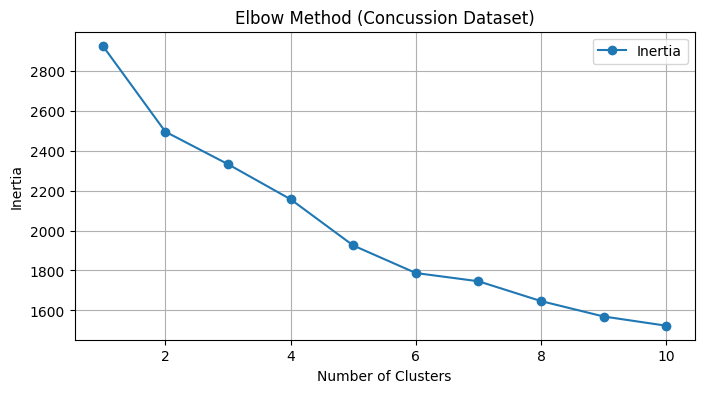

In [95]:
# Concussion Elbow Method
inertia_concussion = []
K_range_concussion = range(1, 11)
for k in K_range_concussion:
    kmeans_concussion = KMeans(n_clusters=k, random_state=42)
    kmeans_concussion.fit(X_concussion_scaled)
    inertia_concussion.append(kmeans_concussion.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range_concussion, inertia_concussion, marker='o', label='Inertia')
plt.title('Elbow Method (Concussion Dataset)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.legend()
plt.show()



k = 2, Silhouette Score = 0.1473
k = 3, Silhouette Score = 0.1405
k = 4, Silhouette Score = 0.1442
k = 5, Silhouette Score = 0.1248
k = 6, Silhouette Score = 0.1173
k = 7, Silhouette Score = 0.1131
k = 8, Silhouette Score = 0.1270
k = 9, Silhouette Score = 0.1116
k = 10, Silhouette Score = 0.1169


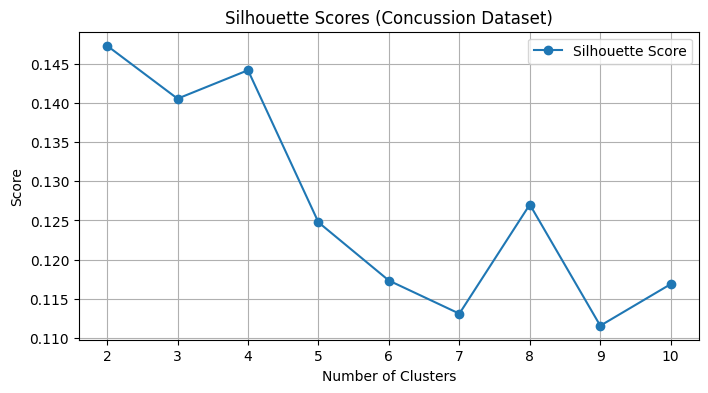

In [96]:
# Concussion Silhouette Score
sil_scores_concussion = []
for k_concussion in range(2, 11):
    kmeans_concussion = KMeans(n_clusters=k_concussion, random_state=42)
    labels_concussion = kmeans_concussion.fit_predict(X_train_scaled_concussion)
    score = silhouette_score(X_train_scaled_concussion, labels_concussion)
    sil_scores_concussion.append(score)
    print(f"k = {k_concussion}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), sil_scores_concussion, marker='o', label='Silhouette Score')
plt.title('Silhouette Scores (Concussion Dataset)')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()


In [97]:
#Concussion Model with Optimal k

optimal_k_concussion = 2
kmeans_final_concussion = KMeans(n_clusters=optimal_k_concussion, random_state=42)
labels_final_concussion = kmeans_final_concussion.fit_predict(X_concussion_scaled)

final_sil_score_concussion = silhouette_score(X_concussion_scaled, labels_final_concussion)
print(f"Final Silhouette Score (k={optimal_k_concussion}): {final_sil_score_concussion:.4f}")


Final Silhouette Score (k=2): 0.1436


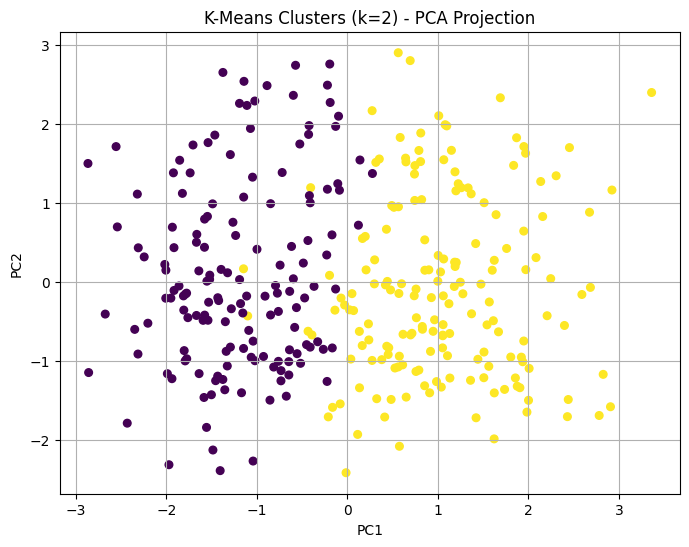

In [99]:
# Concussion PCA Visualization 

pca_concussion = PCA(n_components=2)
concussion_pca = pca_concussion.fit_transform(X_concussion_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(concussion_pca[:, 0], concussion_pca[:, 1], c=labels_final_concussion, cmap='viridis', s=30)
plt.title(f'K-Means Clusters (k={optimal_k_concussion}) - PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)